This is a demo of feature engineering using the OpenCV framework

We will start importing the necessary frameworks

In [5]:
%pip install opencv-python-headless
import cv2
import numpy as np
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 64.9 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


We'll be using an image from a built in dataset in sklearn

In [6]:
image = load_sample_image('china.jpg')

We need to convert the image to BGR format for OpenCV compatability

In [7]:
image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

Next we need to convert the image to grayscale for feature selection

In [8]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

SIFT (Scale-Invariant Feature Transform)

In [9]:
sift = cv2.SIFT_create()
kps_sift, des_sift = sift.detectAndCompute(gray, None)
img_sift = cv2.drawKeypoints(gray, kps_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

## ORB (Oriented FAST and Rotated BRIEF)

In [10]:
orb = cv2.ORB_create()
kps_orb, des_orb = orb.detectAndCompute(gray, None)
img_orb = cv2.drawKeypoints(gray, kps_orb, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

## Harris Corner Detection

In [11]:
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)
img_harris = image_bgr.copy()
img_harris[harris > 0.01 * harris.max()] = [0, 0, 255]

## Shi-Tomasi Corner Detection

In [13]:
corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = np.int32(corners)
img_shi = image_bgr.copy()
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(img_shi, (x, y), 3, 255, -1)

## Canny Edge Detection

In [14]:
edges = cv2.Canny(gray, 100, 200)

# Display results


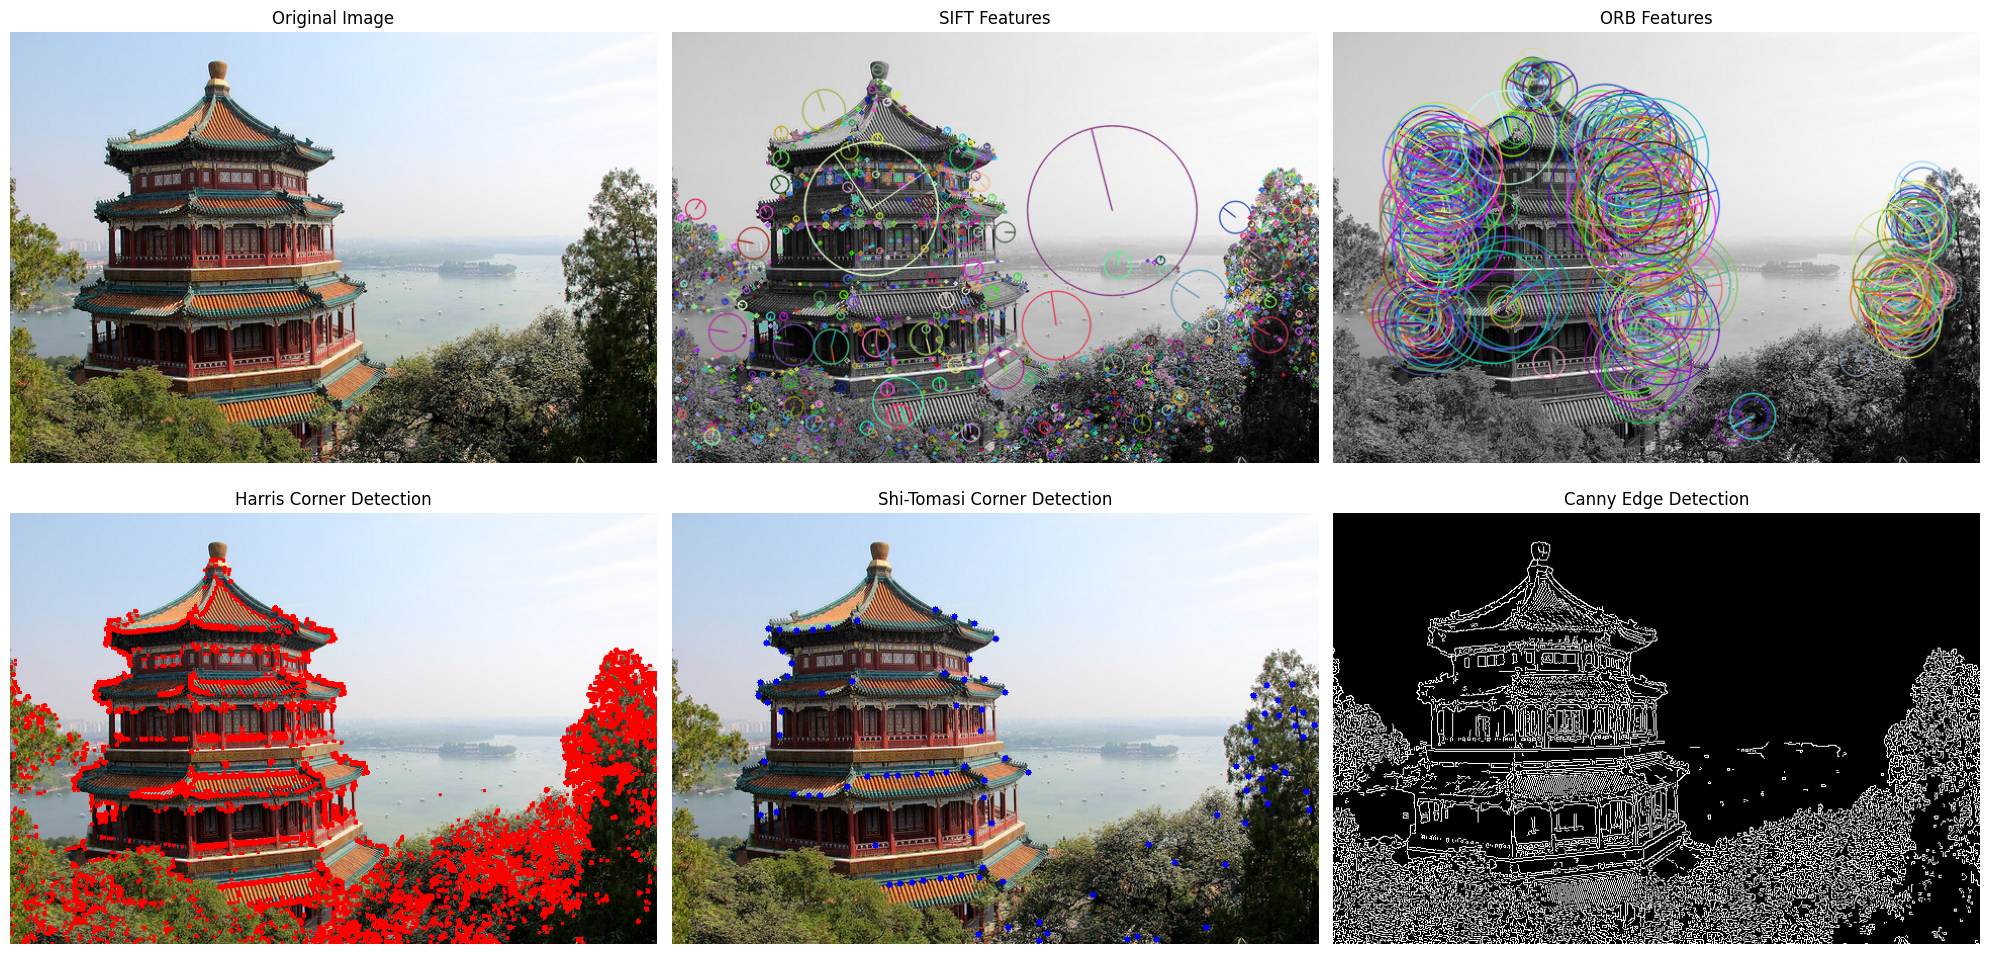

Number of SIFT keypoints: 1621
Number of ORB keypoints: 500
Number of Shi-Tomasi corners: 100


In [25]:
# Display results
plt.figure(figsize=(20, 10))

plt.subplot(231), plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.title('Original Image'), plt.axis('off')

plt.subplot(232), plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title('SIFT Features'), plt.axis('off')

plt.subplot(233), plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB Features'), plt.axis('off')

plt.subplot(234), plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title('Harris Corner Detection'), plt.axis('off')

plt.subplot(235), plt.imshow(cv2.cvtColor(img_shi, cv2.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Corner Detection'), plt.axis('off')

plt.subplot(236), plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection'), plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Number of SIFT keypoints: {len(kps_sift)}")
print(f"Number of ORB keypoints: {len(kps_orb)}")
print(f"Number of Shi-Tomasi corners: {len(corners)}")